In [42]:
import pandas as pd
import numpy as np

In [43]:
data = pd.read_csv('/2- Hotel Reservations.csv')
print("Original shape:", data.shape)

Original shape: (36275, 19)


In [44]:
print("\nDuplicates on full data (including Booking_ID):", data.duplicated().sum())



Duplicates on full data (including Booking_ID): 0


In [45]:
data = data.drop_duplicates()
print("After drop_duplicates on full data:", data.shape)

After drop_duplicates on full data: (36275, 19)


In [46]:
data = data.drop(['Booking_ID', 'arrival_year', 'arrival_date'], axis=1)


In [47]:
print("After dropping columns:", data.shape)
print("Remaining duplicates:", data.duplicated().sum())

After dropping columns: (36275, 16)
Remaining duplicates: 10477


In [48]:
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
    print("Final shape after second dedup:", data.shape)

Final shape after second dedup: (25798, 16)


In [49]:
print("\nNull values:\n", data.isnull().sum())
print("\nData types:\n", data.dtypes)
print("\nTarget distribution:")
print(data['booking_status'].value_counts())
print(data['booking_status'].value_counts(normalize=True).mul(100).round(2))

data.head()


Null values:
 no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_month                           0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

Data types:
 no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int6

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,Online,0,0,0,94.50,0,Canceled


In [50]:
data['booking_status'] = data['booking_status'].map(
    {'Canceled': 1, 'Not_Canceled': 0}
)

In [51]:
print(data.select_dtypes(include='object').columns.tolist())


['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [52]:
from sklearn.preprocessing import LabelEncoder


In [53]:
le = LabelEncoder()
cat_cols = ['type_of_meal_plan', 'room_type_reserved',
            'market_segment_type']

In [54]:
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [55]:
print(data.dtypes)
data.head()

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                         int64
required_car_parking_space                int64
room_type_reserved                        int64
lead_time                                 int64
arrival_month                             int64
market_segment_type                       int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                            int64
dtype: object


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224,10,3,0,0,0,65.00,0,0
1,2,0,2,3,3,0,0,5,11,4,0,0,0,106.68,1,0
2,1,0,2,1,0,0,0,1,2,4,0,0,0,60.00,0,1
3,2,0,0,2,0,0,0,211,5,4,0,0,0,100.00,0,1
4,2,0,1,1,3,0,0,48,4,4,0,0,0,94.50,0,1


In [56]:
from sklearn.model_selection import train_test_split


In [57]:
X = data.drop('booking_status', axis=1)
y = data['booking_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train cancellation rate: {y_train.mean()*100:.2f}%")
print(f"Test cancellation rate:  {y_test.mean()*100:.2f}%")

X_train: (20638, 15)
X_test:  (5160, 15)
Train cancellation rate: 28.77%
Test cancellation rate:  28.78%


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

In [59]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [60]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [61]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [62]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model
}


In [63]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_prob > 0.5))
    print(f"AUC-ROC: {auc:.4f}")


  Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      3675
           1       0.70      0.55      0.62      1485

    accuracy                           0.80      5160
   macro avg       0.77      0.73      0.74      5160
weighted avg       0.80      0.80      0.80      5160

AUC-ROC: 0.8470

  Random Forest
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      3675
           1       0.77      0.68      0.72      1485

    accuracy                           0.85      5160
   macro avg       0.82      0.80      0.81      5160
weighted avg       0.85      0.85      0.85      5160

AUC-ROC: 0.8992

  XGBoost
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3675
           1       0.79      0.68      0.73      1485

    accuracy                           0.85      5160
   macro avg       0.83      0.80      0.81  

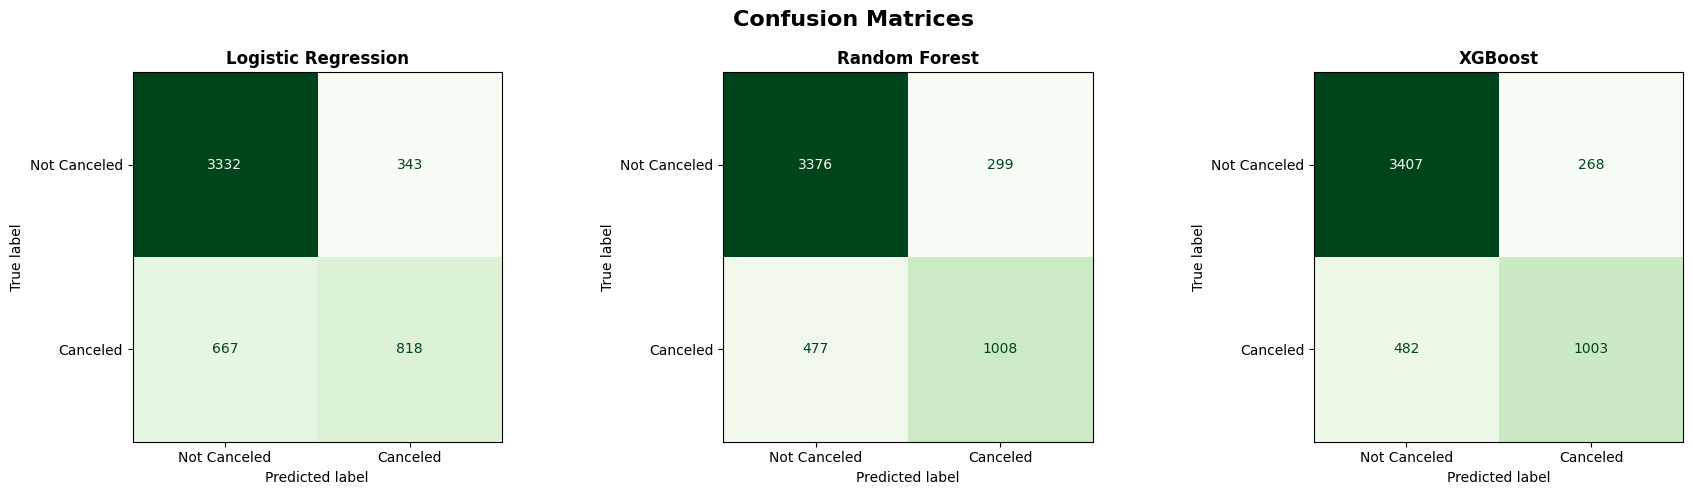

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Canceled', 'Canceled'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

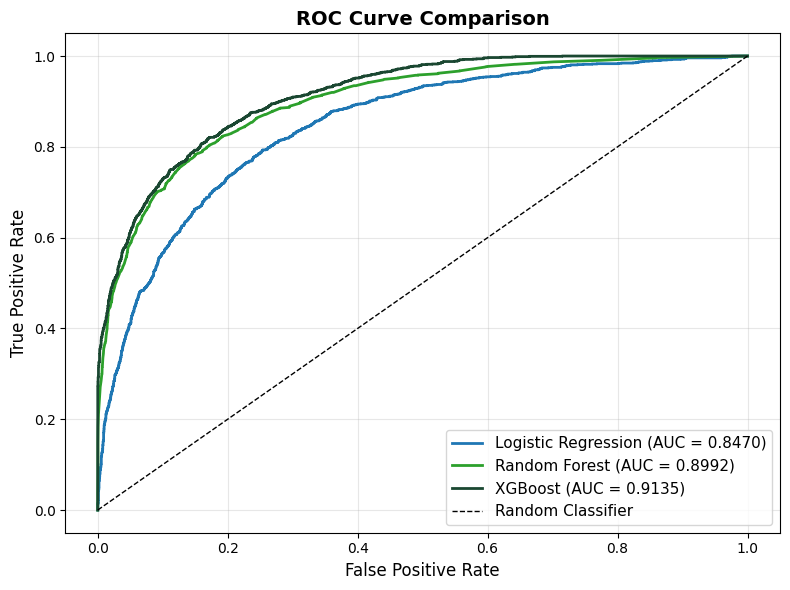

In [65]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#1A4731']
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

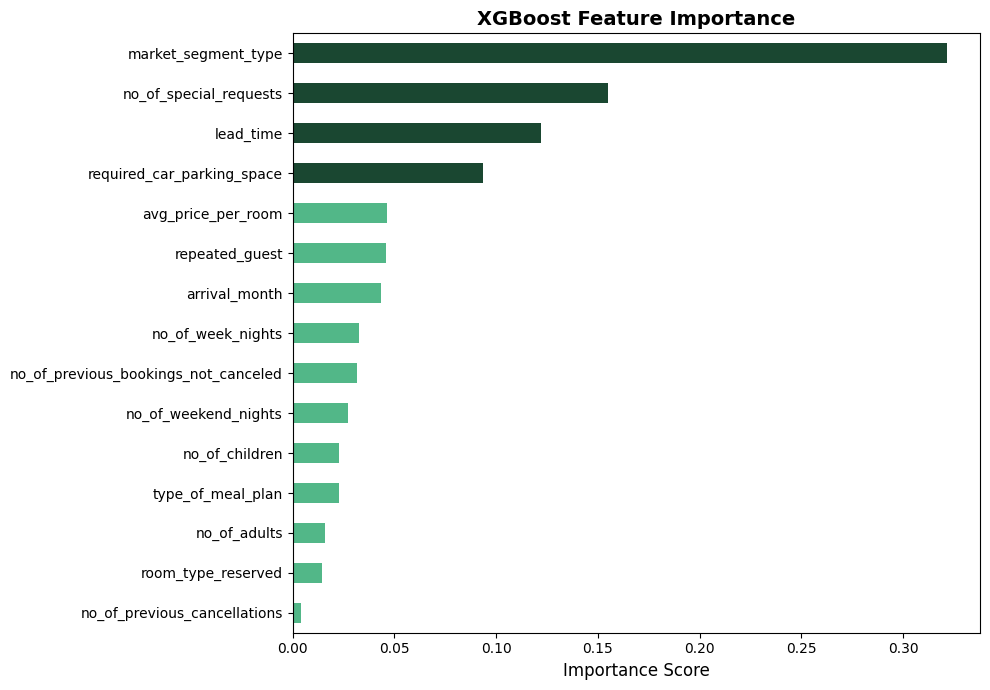

In [66]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#1A4731' if v >= feat_imp.quantile(0.75) else '#52B788'
          for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

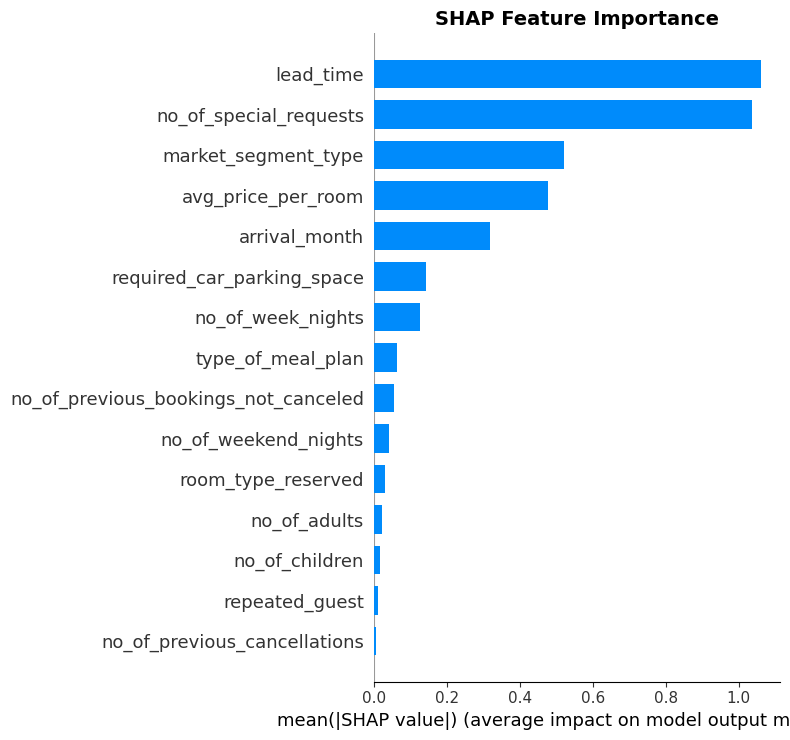

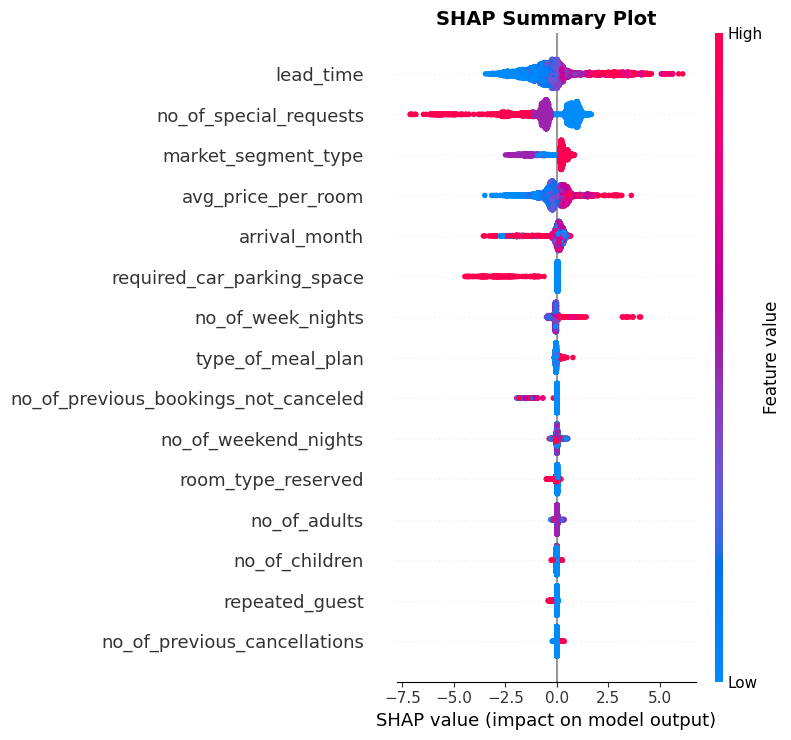

In [70]:
# ── 10. SHAP Values ───────────────────────────────────
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed SHAP dot plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title('SHAP Summary Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression     80.43      70.46   55.08     61.83   0.8470
      Random Forest     84.96      77.12   67.88     72.21   0.8992
            XGBoost     85.47      78.91   67.54     72.79   0.9135
